In [80]:

import matplotlib.pyplot as plt
import pandas as pd
import plotly.graph_objects as go
import numpy as np

StatementMeta(, cac98411-7c8f-47bd-95e5-1d19256c3666, 82, Finished, Available, Finished)

In [81]:
# ─────────────────────────────────────────────────────────────
# Paso 5.3.1: Generación de variables temporales
# Notebook: TFM_Ingenieria.ipynb
# ─────────────────────────────────────────────────────────────

# Cargar tabla desde Silver (Lakehouse)
df_spark = spark.read.table("Silver.BD_ARANDA_SILVER")
df = df_spark.toPandas()

print(f"✅ Dataset cargado con éxito desde Silver: {df.shape[0]} filas × {df.shape[1]} columnas")

# ─────────────────────────────────────────────────────────────
# Conversión segura de columnas de fechas
# ─────────────────────────────────────────────────────────────

columnas_fecha = [
    'Fecha_de_Registro',
    'Fecha_Solución',
    'Fecha_Cierre',
    'Fecha_último_Estado',
    'Fecha_Entrega_Esperada'
]

for col in columnas_fecha:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
print("📆 Fechas convertidas correctamente a tipo datetime.")

# ─────────────────────────────────────────────────────────────
# Verificación o generación de 'tiempo_resolucion_dias'
# ─────────────────────────────────────────────────────────────

if 'tiempo_resolucion_dias' in df.columns:
    print("🔎 La columna 'tiempo_resolucion_dias' ya existe y será utilizada.")
else:
    print("⚠️ La columna 'tiempo_resolucion_dias' no fue encontrada. Se recalcula.")
    
    # Calcular días entre Registro y Solución
    df['tiempo_resolucion_dias'] = (df['Fecha_Solución'] - df['Fecha_de_Registro']).dt.days
    
    # Invalidar duraciones negativas
    df.loc[df['tiempo_resolucion_dias'] < 0, 'tiempo_resolucion_dias'] = None
    print("🛠️ Variable 'tiempo_resolucion_dias' generada nuevamente.")


# ─────────────────────────────────────────────────────────────
# Clasificación de casos triviales: Generar columna 'tipo_resolucion'
# ─────────────────────────────────────────────────────────────

df['tipo_resolucion'] = df['tiempo_resolucion_dias'].apply(
    lambda x: "Trivial" if x == 0 else "No Trivial"
)

# Contar distribución
conteo_trivial = df['tipo_resolucion'].value_counts()
print("📊 Clasificación de casos por tipo de resolución:")
print(conteo_trivial)

# Marcar columna binaria auxiliar (opcional si se requiere como dummy)
df['es_trivial'] = df['tipo_resolucion'].apply(lambda x: 1 if x == "Trivial" else 0)

# Vista previa
display(df[['Caso', 'tiempo_resolucion_dias', 'tipo_resolucion']].head())

# ─────────────────────────────────────────────────────────────
# Vista previa de variables clave
# ─────────────────────────────────────────────────────────────

display(df[['Caso', 'Fecha_de_Registro', 'Fecha_Solución', 'tiempo_resolucion_dias','tipo_resolucion']].head())



StatementMeta(, cac98411-7c8f-47bd-95e5-1d19256c3666, 83, Finished, Available, Finished)

✅ Dataset cargado con éxito desde Silver: 19748 filas × 59 columnas
📆 Fechas convertidas correctamente a tipo datetime.
🔎 La columna 'tiempo_resolucion_dias' ya existe y será utilizada.
📊 Clasificación de casos por tipo de resolución:
tipo_resolucion
No Trivial    13165
Trivial        6583
Name: count, dtype: int64


,Caso,tiempo_resolucion_dias,tipo_resolucion
0,180010079,17,No Trivial
1,180010078,7,No Trivial
2,180010077,0,Trivial
3,180010068,6,No Trivial
4,180010067,3,No Trivial


,Caso,Fecha_de_Registro,Fecha_Solución,tiempo_resolucion_dias,tipo_resolucion
0,180010079,2020-06-02,2020-06-19,17,No Trivial
1,180010078,2020-06-02,2020-06-09,7,No Trivial
2,180010077,2020-06-02,2020-06-02,0,Trivial
3,180010068,2020-06-02,2020-06-08,6,No Trivial
4,180010067,2020-06-02,2020-06-05,3,No Trivial


StatementMeta(, cac98411-7c8f-47bd-95e5-1d19256c3666, 84, Finished, Available, Finished)

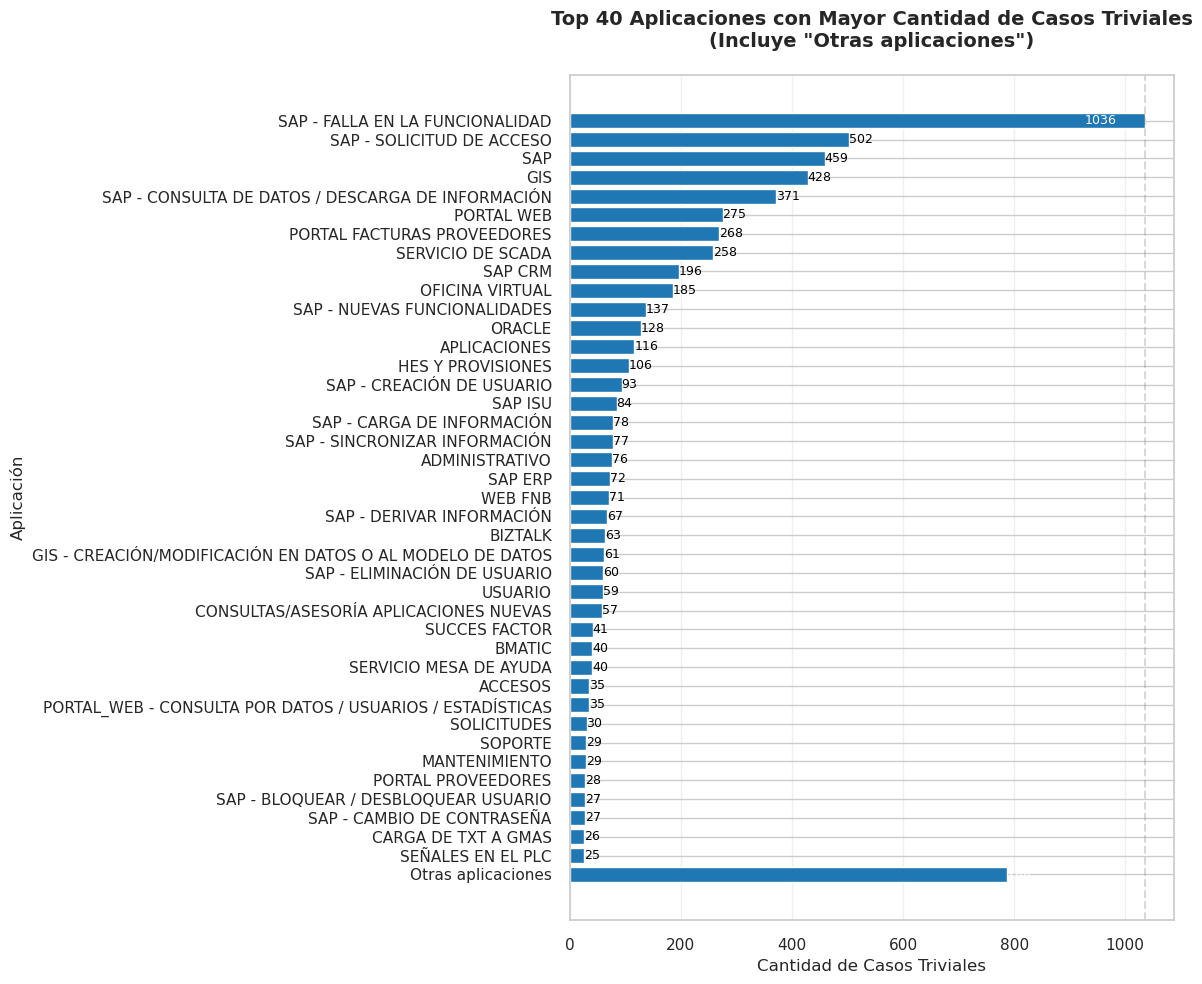

,Aplicación,Cantidad_Triviales,Proporcion_Triviales
0,SAP - FALLA EN LA FUNCIONALIDAD,1036,0.481000
1,SAP - SOLICITUD DE ACCESO,502,0.435000
2,SAP,459,0.217000
3,GIS,428,0.325000
4,SAP - CONSULTA DE DATOS / DESCARGA DE INFORMACIÓN,371,0.518000
5,PORTAL WEB,275,0.208000
6,PORTAL FACTURAS PROVEEDORES,268,0.632000
7,SERVICIO DE SCADA,258,0.893000
8,SAP CRM,196,0.366000
9,OFICINA VIRTUAL,185,0.285000


In [82]:
# ─────────────────────────────────────────────────────────────
# Análisis de casos triviales según el campo 'Aplicación'
# ─────────────────────────────────────────────────────────────

# Filtrar solo los casos triviales
df_triviales = df[df['tipo_resolucion'] == "Trivial"]

# Conteo de casos triviales por aplicación
conteo_por_aplicacion = df_triviales['Aplicación'].value_counts().reset_index()
conteo_por_aplicacion.columns = ['Aplicación', 'Cantidad_Triviales']

# Total de casos por aplicación (para calcular proporción)
total_por_aplicacion = df['Aplicación'].value_counts().reset_index()
total_por_aplicacion.columns = ['Aplicación', 'Total_Casos']

# Unir ambos conteos y calcular proporción de triviales
df_aplicacion_triviales = pd.merge(conteo_por_aplicacion, total_por_aplicacion, on='Aplicación')
df_aplicacion_triviales['Proporcion_Triviales'] = (
    df_aplicacion_triviales['Cantidad_Triviales'] / df_aplicacion_triviales['Total_Casos']
).round(3)

# Ordenar por cantidad descendente
df_aplicacion_triviales.sort_values(by='Cantidad_Triviales', ascending=False, inplace=True)

# ─────────────────────────────────────────────────────────────
# Preparación de datos para el gráfico con categoría "Otros"
# ─────────────────────────────────────────────────────────────
top_n = 40
df_top = df_aplicacion_triviales.head(top_n).copy()

# Calcular la suma de las demás aplicaciones
otros_total = df_aplicacion_triviales['Cantidad_Triviales'][top_n:].sum()

# Crear fila para "Otros" si hay valores restantes
if otros_total > 0:
    otros_row = pd.DataFrame({
        'Aplicación': ['Otras aplicaciones'],
        'Cantidad_Triviales': [otros_total],
        'Total_Casos': [df_aplicacion_triviales['Total_Casos'][top_n:].sum()],
        'Proporcion_Triviales': [otros_total / df_aplicacion_triviales['Total_Casos'][top_n:].sum()]
    })
    df_top = pd.concat([df_top, otros_row], ignore_index=True)

# ─────────────────────────────────────────────────────────────
# Gráfico mejorado
# ─────────────────────────────────────────────────────────────
plt.figure(figsize=(12, 10))

# Barras principales
bars = plt.barh(df_top['Aplicación'], df_top['Cantidad_Triviales'], color='#1f77b4')

# Establecer límites del eje x basado en el valor máximo
max_value = df_top['Cantidad_Triviales'].max()
plt.xlim(0, max_value * 1.05)  # 5% de margen para las etiquetas

# Añadir etiquetas
for bar in bars:
    width = bar.get_width()
    label_x = width if width < max_value * 0.9 else width * 0.95
    plt.text(label_x, bar.get_y() + bar.get_height()/2, 
             f'{int(width)}', 
             va='center', ha='right' if width >= max_value * 0.9 else 'left',
             color='white' if width >= max_value * 0.5 else 'black',
             fontsize=9)

# Personalización adicional
plt.gca().invert_yaxis()  # Barra más grande arriba
plt.xlabel('Cantidad de Casos Triviales', fontsize=12)
plt.ylabel('Aplicación', fontsize=12)
plt.title(f'Top {top_n} Aplicaciones con Mayor Cantidad de Casos Triviales\n(Incluye "Otras aplicaciones")', 
          fontsize=14, pad=20)

# Añadir línea vertical para el valor máximo
plt.axvline(x=max_value, color='gray', linestyle='--', alpha=0.3)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Opcional: Mostrar tabla con los datos
display(df_top[['Aplicación', 'Cantidad_Triviales', 'Proporcion_Triviales']].head(top_n+1))

In [83]:
# ─────────────────────────────────────────────────────────────
# Paso 5.3.1.1 - Derivación de variables temporales por fases (mejorado)
# ─────────────────────────────────────────────────────────────

# Asegurar columnas datetime
columnas_fechas = [
    'Fecha_de_Registro',
    'Fecha_último_Estado',
    'Fecha_Solución',
    'Fecha_Cierre',
    'Fecha_Entrega_Esperada'
]

for col in columnas_fechas:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# 1️⃣ duración desde creación hasta el último estado
df['duracion_creacion_a_estado'] = (df['Fecha_último_Estado'] - df['Fecha_de_Registro']).dt.days
df.loc[df['duracion_creacion_a_estado'] < 0, 'duracion_creacion_a_estado'] = None

# 2️⃣ duración desde creación hasta la solución
df['duracion_creacion_a_solucion'] = (df['Fecha_Solución'] - df['Fecha_de_Registro']).dt.days
df.loc[df['duracion_creacion_a_solucion'] < 0, 'duracion_creacion_a_solucion'] = None

# 3️⃣ duración desde solución hasta el cierre
df['duracion_solucion_a_cierre'] = (df['Fecha_Cierre'] - df['Fecha_Solución']).dt.days
df.loc[df['duracion_solucion_a_cierre'] < 0, 'duracion_solucion_a_cierre'] = None

# 4️⃣ diferencia entre solución y entrega esperada
df['retraso_vs_entrega_esperada'] = (df['Fecha_Solución'] - df['Fecha_Entrega_Esperada']).dt.days

# Nueva columna interpretativa: Retraso / Anticipado / No Definido
def clasificar_retraso(valor, fecha_sol, fecha_cierre):
    """
    Clasifica el estado de entrega basado en la diferencia de días y la existencia de fechas clave.

    Parámetros:
    - valor: diferencia en días entre Fecha_Solución y Fecha_Entrega_Esperada
    - fecha_sol: valor de Fecha_Solución
    - fecha_cierre: valor de Fecha_Cierre

    Retorna:
    - Etiqueta categórica
    """
    if pd.notna(fecha_sol) and pd.isna(fecha_cierre):
        return "Error Cierre"
    elif pd.isna(valor):
        return "No Definido"
    elif valor > 0:
        return "Retraso"
    elif valor < 0:
        return "Anticipado"
    else:
        return "En Fecha Exacta"

# Aplicar la función fila por fila con acceso a múltiples columnas
df['estado_retraso_entrega'] = df.apply(
    lambda row: clasificar_retraso(
        row['retraso_vs_entrega_esperada'],
        row['Fecha_Solución'],
        row['Fecha_Cierre']
    ), axis=1
)


# Vista previa
display(df[[
    'Caso',
    'Fecha_Entrega_Esperada', 'Fecha_Solución', 'duracion_creacion_a_estado', 'duracion_creacion_a_solucion', 'duracion_solucion_a_cierre',
    'retraso_vs_entrega_esperada', 'estado_retraso_entrega'
]].sample(5))



StatementMeta(, cac98411-7c8f-47bd-95e5-1d19256c3666, 85, Finished, Available, Finished)

,Caso,Fecha_Entrega_Esperada,Fecha_Solución,duracion_creacion_a_estado,duracion_creacion_a_solucion,duracion_solucion_a_cierre,retraso_vs_entrega_esperada,estado_retraso_entrega
3079,180005791,2019-07-01 14:59:43,2019-06-25,0.0,0.0,0.0,-7.0,Anticipado
9262,185040906,2020-07-23 15:47:48,2020-07-31,33.0,28.0,5.0,7.0,Retraso
2861,185052756,2021-02-18 11:22:50,2021-01-29,9.0,4.0,5.0,-21.0,Anticipado
7265,185018853,2019-08-02 19:00:00,2019-07-30,2.0,0.0,2.0,-4.0,Anticipado
9276,185042465,2020-07-31 10:47:06,2020-07-31,5.0,0.0,5.0,-1.0,Anticipado


StatementMeta(, cac98411-7c8f-47bd-95e5-1d19256c3666, 86, Finished, Available, Finished)

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1765: FutureWarning:

unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.

/tmp/ipykernel_6146/1995306806.py:61: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from current font.

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from current font.



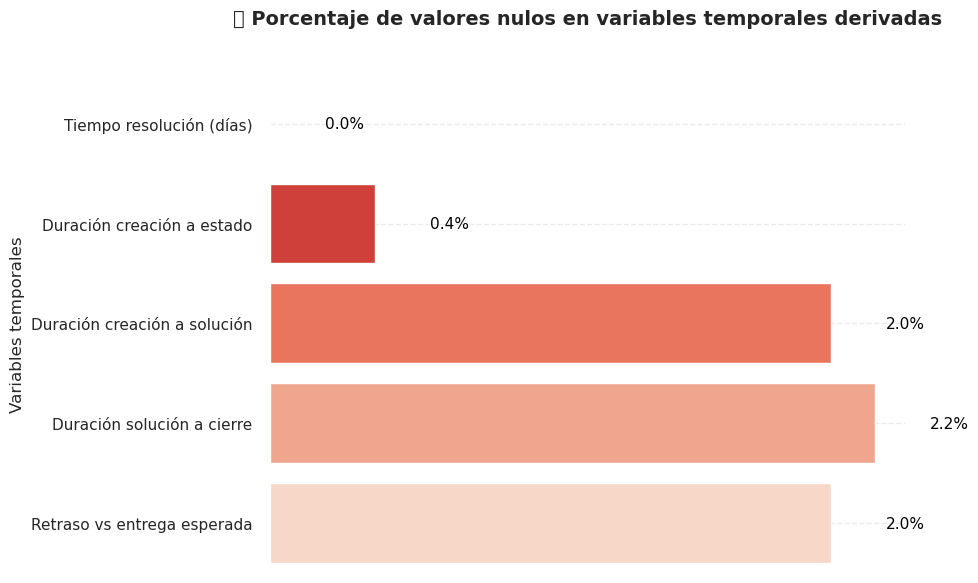

In [84]:
# ─────────────────────────────────────────────────────────────
# Paso 5.3.2. - Eliminación de variables redundantes
# ─────────────────────────────────────────────────────────────
# ─────────────────────────────────────────────────────────────
# Paso 5.3.2.1 - Visualización sin etiquetas del eje X
# ─────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'

# Variables temporales con nombres presentables
variables_temporales = {
    'tiempo_resolucion_dias': 'Tiempo resolución (días)',
    'duracion_creacion_a_estado': 'Duración creación a estado',
    'duracion_creacion_a_solucion': 'Duración creación a solución',
    'duracion_solucion_a_cierre': 'Duración solución a cierre',
    'retraso_vs_entrega_esperada': 'Retraso vs entrega esperada'
}

# Calcular porcentaje de nulos
porcentaje_nulos = (df[list(variables_temporales.keys())].isnull().mean() * 100).round(2)

# Crear figura con tamaño adecuado
plt.figure(figsize=(10, 6))

# Gráfico de barras horizontales mejorado
ax = sns.barplot(
    x=porcentaje_nulos.values,
    y=[variables_temporales[v] for v in porcentaje_nulos.index],
    palette="Reds_r",
    saturation=0.8
)

# Personalización del gráfico
plt.title('📊 Porcentaje de valores nulos en variables temporales derivadas\n', 
          fontsize=14, pad=20)
plt.xlabel('')  # Eliminamos el label del eje X
plt.ylabel('Variables temporales', fontsize=12)

# Eliminar etiquetas del eje X
ax.set_xticklabels([])
ax.set_xticks([])  # Esto remueve completamente las marcas del eje X

# Añadir etiquetas de valor sobre las barras
for i, v in enumerate(porcentaje_nulos):
    ax.text(v + 0.2, i, f"{v:.1f}%", 
            color='black', va='center', fontsize=11)

# Mejorar gridlines (también eliminamos los gridlines del eje X)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

# Remover bordes
sns.despine(left=True, bottom=True)

# Ajustar layout
plt.tight_layout()
plt.show()


StatementMeta(, cac98411-7c8f-47bd-95e5-1d19256c3666, 87, Finished, Available, Finished)

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instea

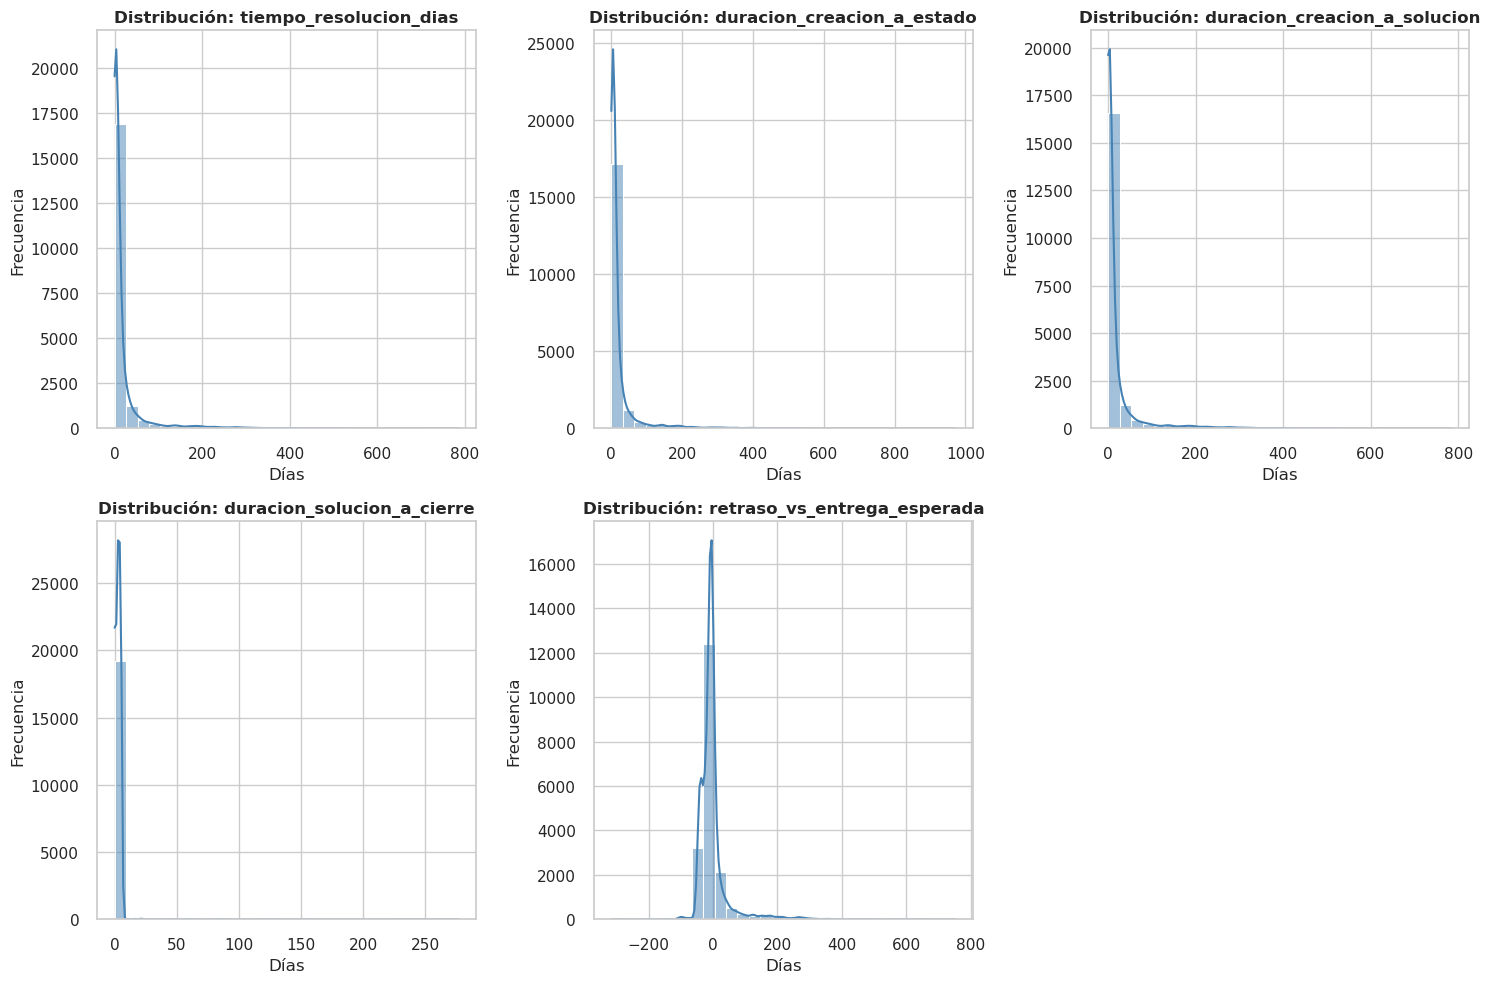

In [85]:
# ─────────────────────────────────────────────────────────────
#  Paso 5.3.2.2 - Distribución de variables temporales derivadas
# ─────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import seaborn as sns

# Variables numéricas a graficar
vars_numericas = [
    'tiempo_resolucion_dias',
    'duracion_creacion_a_estado',
    'duracion_creacion_a_solucion',
    'duracion_solucion_a_cierre',
    'retraso_vs_entrega_esperada'
]

# Crear histogramas
plt.figure(figsize=(15, 10))
for i, col in enumerate(vars_numericas, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col].dropna(), bins=30, kde=True, color='steelblue')
    plt.title(f'Distribución: {col}')
    plt.xlabel('Días')
    plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()




StatementMeta(, cac98411-7c8f-47bd-95e5-1d19256c3666, 88, Finished, Available, Finished)

/tmp/ipykernel_6146/3843403801.py:46: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from current font.

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from current font.



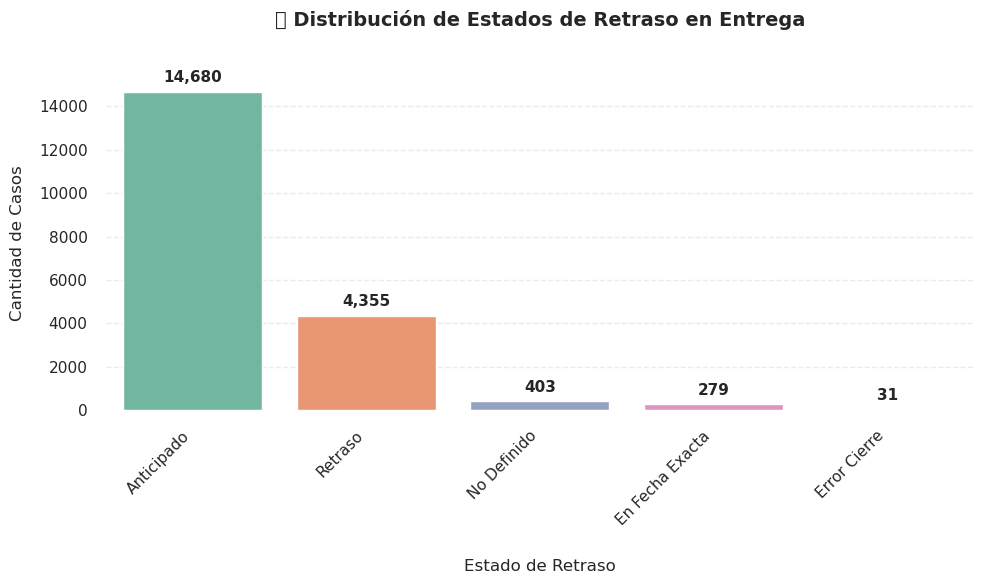

In [86]:
# ─────────────────────────────────────────────────────────────
# Paso 5.3.2.3 - Visualización mejorada de variable categórica
# ─────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.titleweight'] = 'bold'

# Preparar datos
conteos = df['estado_retraso_entrega'].value_counts()
paleta = sns.color_palette("Set2")

# Crear figura
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=conteos.index, y=conteos.values, palette=paleta)

# Personalización del gráfico
plt.title("📊 Distribución de Estados de Retraso en Entrega\n", 
          fontsize=14, pad=20)
plt.xlabel("\nEstado de Retraso", fontsize=12, labelpad=10)
plt.ylabel("Cantidad de Casos", fontsize=12, labelpad=10)

# Mejorar gridlines
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

# Añadir etiquetas con formato
for i, (index, value) in enumerate(conteos.items()):
    ax.text(i, value + max(conteos)*0.02, f"{value:,}", 
            ha='center', va='bottom', 
            fontsize=11, fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))

# Rotar etiquetas del eje X si son largas
if any(len(str(x)) > 10 for x in conteos.index):
    plt.xticks(rotation=45, ha='right')

# Remover bordes
sns.despine(left=True, bottom=True)

# Ajustar layout
plt.tight_layout()
plt.show()


In [87]:
# ─────────────────────────────────────────────────────────────
# Mostrar muestra de casos con estado_retraso_entrega = "No Definido" (con Fecha_Cierre)
# ─────────────────────────────────────────────────────────────

# Filtrar registros con estado no definido
filtro_nd = df['estado_retraso_entrega'] == "No Definido"
muestra_nd = df[filtro_nd][[
    'Caso',
    'Fecha_Entrega_Esperada',
    'Fecha_Solución',
    'Fecha_Cierre',
    'retraso_vs_entrega_esperada',
    'estado_retraso_entrega'
]].copy()

# Mostrar muestra aleatoria de 5 registros
muestra_nd.sample(5, random_state=42)



StatementMeta(, cac98411-7c8f-47bd-95e5-1d19256c3666, 89, Finished, Available, Finished)

,Caso,Fecha_Entrega_Esperada,Fecha_Solución,Fecha_Cierre,retraso_vs_entrega_esperada,estado_retraso_entrega
7634,185086274,2022-06-01 13:00:00,NaT,NaT,NaN,No Definido
17034,185075719,2022-02-03 10:53:56,NaT,NaT,NaN,No Definido
18309,185072845,2022-01-03 16:57:20,NaT,NaT,NaN,No Definido
5698,185086170,2022-05-31 18:00:00,NaT,NaT,NaN,No Definido
6403,185086446,2022-06-03 09:47:23,NaT,NaT,NaN,No Definido


In [88]:
# ─────────────────────────────────────────────────────────────
# Mostrar casos con Fecha_Solución definida pero sin Fecha_Cierre
# ─────────────────────────────────────────────────────────────

# Asegurar tipos datetime por si hubo reinicio de sesión
df['Fecha_Solución'] = pd.to_datetime(df['Fecha_Solución'], errors='coerce')
df['Fecha_Cierre'] = pd.to_datetime(df['Fecha_Cierre'], errors='coerce')

# Filtrar registros con solución pero sin cierre
filtro_sol_sin_cierre = df['Fecha_Solución'].notna() & df['Fecha_Cierre'].isna()
casos_sol_sin_cierre = df[filtro_sol_sin_cierre][[
    'Caso',
    'Fecha_de_Registro',
    'Fecha_Solución',
    'Fecha_Cierre',
    'estado_retraso_entrega'
]]

# Mostrar resultado (primeras filas)
casos_sol_sin_cierre.head(10)


StatementMeta(, cac98411-7c8f-47bd-95e5-1d19256c3666, 90, Finished, Available, Finished)

,Caso,Fecha_de_Registro,Fecha_Solución,Fecha_Cierre,estado_retraso_entrega
5642,185086581,2022-04-25,2022-04-27,NaT,Error Cierre
6884,180014714,2021-05-30,2021-05-30,NaT,Error Cierre
6885,180028210,2022-04-28,2022-04-28,NaT,Error Cierre
6886,180027546,2022-04-14,2022-04-27,NaT,Error Cierre
7629,185058756,2021-05-03,2021-05-30,NaT,Error Cierre
7630,185058757,2021-05-03,2021-05-30,NaT,Error Cierre
12164,180027711,2022-04-19,2022-04-19,NaT,Error Cierre
15636,185086598,2022-04-25,2022-04-26,NaT,Error Cierre
16078,180004870,2019-05-14,2019-10-30,NaT,Error Cierre
16422,180020540,2021-10-26,2022-01-19,NaT,Error Cierre


In [89]:
# ─────────────────────────────────────────────────────────────
#  Paso 5.3.2.4 - Filtrar registros válidos para análisis de entrega
# ─────────────────────────────────────────────────────────────

# Eliminar estados no deseados
estados_invalidos = ["No Definido", "Error Cierre"]
filas_antes = df.shape[0]
df = df[~df['estado_retraso_entrega'].isin(estados_invalidos)].copy()
filas_despues = df.shape[0]

# Confirmar
print(f"🧹 Filas eliminadas: {filas_antes - filas_despues}")
print(f"📦 Dataset resultante → {df.shape[0]} filas × {df.shape[1]} columnas")


StatementMeta(, cac98411-7c8f-47bd-95e5-1d19256c3666, 91, Finished, Available, Finished)

🧹 Filas eliminadas: 434
📦 Dataset resultante → 19314 filas × 66 columnas


In [90]:
# ─────────────────────────────────────────────────────────────
# Paso : Guardar tabla Gold - bd_aranda_gold_dashboard
# ─────────────────────────────────────────────────────────────

# Reemplazar Inf y NaN por None para evitar errores de conversión
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.where(pd.notnull(df), None)

# Convertir a DataFrame Spark
df_spark_dashboard = spark.createDataFrame(df)

# Renombrar columnas para evitar espacios (recomendado en SQL)
df_spark_dashboard_clean = df_spark_dashboard.toDF(*[col.replace(" ", "_") for col in df_spark_dashboard.columns])

# Nombre de tabla destino en Gold
nombre_tabla_gold = "Gold.bd_aranda_gold_dashboard"

# Eliminar tabla si ya existe (para prevenir conflictos)
spark.sql(f"DROP TABLE IF EXISTS {nombre_tabla_gold}")

# Guardar como nueva tabla Delta en Gold
df_spark_dashboard_clean.write.mode("overwrite").saveAsTable(nombre_tabla_gold)

print("✅ Tabla 'bd_aranda_gold_dashboard' eliminada y recreada exitosamente en Gold.")


StatementMeta(, cac98411-7c8f-47bd-95e5-1d19256c3666, 92, Finished, Available, Finished)

✅ Tabla 'bd_aranda_gold_dashboard' eliminada y recreada exitosamente en Gold.


In [91]:
# ─────────────────────────────────────────────────────────────
# Filtrar solo casos "No Triviales" antes de análisis de modelado
# ─────────────────────────────────────────────────────────────

# Asegurarse de que existe la columna tipo_resolucion
if 'tipo_resolucion' in df.columns:
    total_antes = df.shape[0]
    df = df[df['tipo_resolucion'] == "No Trivial"].copy()
    total_despues = df.shape[0]
    print(f"📌 Filtrado aplicado: {total_antes - total_despues} casos triviales eliminados.")
    print(f"✅ Casos No Triviales restantes: {total_despues}")
else:
    print("⚠️ Advertencia: columna 'tipo_resolucion' no encontrada. No se aplicó filtrado.")


StatementMeta(, cac98411-7c8f-47bd-95e5-1d19256c3666, 93, Finished, Available, Finished)

📌 Filtrado aplicado: 6578 casos triviales eliminados.
✅ Casos No Triviales restantes: 12736


In [92]:


# ─────────────────────────────────────────────────────────────
# 🔍 Matriz de correlación excluyendo 'Cantidad_cerrado'
# ─────────────────────────────────────────────────────────────

# Filtrar todas las columnas numéricas excepto 'Cantidad_cerrado'
numericas = df.select_dtypes(include=['int64', 'float64']).drop(columns=['Cantidad_cerrado','tipo_resolucion','es_trivial','ID'], errors='ignore')

# Calcular matriz de correlación
matriz_corr = numericas.corr().round(2)

# Preparar datos para plotly
z = matriz_corr.values
x = matriz_corr.columns.tolist()
y = matriz_corr.index.tolist()

# Crear etiquetas de texto para cada celda
text_labels = [[f"{z[i][j]:.2f}" for j in range(len(x))] for i in range(len(y))]

# Capa de calor base
heatmap = go.Heatmap(
    z=z,
    x=x,
    y=y,
    colorscale='Oranges',
    zmin=-1,
    zmax=1,
    text=[[f"Correlación: {z[i][j]:.2f}" for j in range(len(x))] for i in range(len(y))],
    hoverinfo="text",
    showscale=True
)

# Superponer texto de correlación
text_overlay = go.Scatter(
    x=np.repeat(x, len(y)),
    y=y * len(x),
    mode="text",
    text=[f"{z[j][i]:.2f}" for i in range(len(x)) for j in range(len(y))],
    textfont=dict(color="black", size=12),
    hoverinfo="skip"
)

# Construir figura final
fig = go.Figure(data=[heatmap, text_overlay])

fig.update_layout(
    title="🔍 Matriz de Correlación - Todas las Variables Numéricas (sin 'Cantidad_cerrado')",
    xaxis=dict(tickangle=-45),
    yaxis=dict(autorange='reversed'),
    width=1000,
    height=900
)

fig.show()





StatementMeta(, cac98411-7c8f-47bd-95e5-1d19256c3666, 94, Finished, Available, Finished)

In [93]:
# ─────────────────────────────────────────────────────────────
# Ver correlaciones entre pares de variables numéricas (sin mapa)
# ─────────────────────────────────────────────────────────────

# Filtrar variables numéricas excluyendo 'Cantidad_cerrado'
numericas = df.select_dtypes(include=['int64', 'float64']).drop(columns=['Cantidad_cerrado','tipo_resolucion','es_trivial','ID'], errors='ignore')

# Eliminar registros con valores nulos
df_corr_check = numericas.dropna()

# Mostrar correlación explícita entre pares
print("📌 Correlaciones entre pares de variables numéricas (sin 'Cantidad_cerrado'):\n")
for i in range(len(df_corr_check.columns)):
    for j in range(i + 1, len(df_corr_check.columns)):
        col1 = df_corr_check.columns[i]
        col2 = df_corr_check.columns[j]
        coef = df_corr_check[col1].corr(df_corr_check[col2])
        print(f"🔸 {col1} ↔ {col2}: {coef:.4f}")


StatementMeta(, cac98411-7c8f-47bd-95e5-1d19256c3666, 95, Finished, Available, Finished)

📌 Correlaciones entre pares de variables numéricas (sin 'Cantidad_cerrado'):

🔸 SLA_Minutos ↔ Tiempo_transcurrido: -0.0627
🔸 SLA_Minutos ↔ Tiempo_de_Respuesta: -0.1069
🔸 SLA_Minutos ↔ Días_pendientes: -0.7627
🔸 SLA_Minutos ↔ Dias: -0.0791
🔸 SLA_Minutos ↔ Dias_Del_Estado: -0.7695
🔸 SLA_Minutos ↔ tiempo_resolucion_dias: -0.0666
🔸 SLA_Minutos ↔ duracion_creacion_a_estado: -0.0447
🔸 SLA_Minutos ↔ duracion_creacion_a_solucion: -0.0666
🔸 SLA_Minutos ↔ duracion_solucion_a_cierre: 0.0743
🔸 SLA_Minutos ↔ retraso_vs_entrega_esperada: -0.2544
🔸 Tiempo_transcurrido ↔ Tiempo_de_Respuesta: 0.5892
🔸 Tiempo_transcurrido ↔ Días_pendientes: 0.1937
🔸 Tiempo_transcurrido ↔ Dias: 0.6869
🔸 Tiempo_transcurrido ↔ Dias_Del_Estado: 0.0903
🔸 Tiempo_transcurrido ↔ tiempo_resolucion_dias: 0.7435
🔸 Tiempo_transcurrido ↔ duracion_creacion_a_estado: 0.6355
🔸 Tiempo_transcurrido ↔ duracion_creacion_a_solucion: 0.7435
🔸 Tiempo_transcurrido ↔ duracion_solucion_a_cierre: 0.0326
🔸 Tiempo_transcurrido ↔ retraso_vs_entrega_

In [94]:
# ─────────────────────────────────────────────────────────────
#  Paso 5.3.2.5 -- Clasificación de columnas numéricas para eliminar o mantener
# ─────────────────────────────────────────────────────────────

# Lista de columnas evaluadas
variables_numericas = df.select_dtypes(include='number').columns.tolist()

# Etiquetar cada variable según recomendación basada en correlaciones
recomendaciones = []

for col in variables_numericas:
    if col in ['duracion_creacion_a_solucion', 'duracion_creacion_a_estado']:
        recomendaciones.append("Eliminar (redundante con tiempo_resolucion_dias)")
    elif col == 'Días_pendientes':
        recomendaciones.append("Eliminar (correlación alta con Dias_Del_Estado)")
    elif col == 'ID':
        recomendaciones.append("Eliminar (es un identificador)")
    else:
        recomendaciones.append("Mantener")

# Crear DataFrame resumen
df_recomendacion_columnas = pd.DataFrame({
    'Variable': variables_numericas,
    'Recomendacion': recomendaciones
})

# Mostrar resultado (compatible con Jupyter y Fabric si ace_tools no está disponible)
print("📌 Recomendación de tratamiento de columnas numéricas:")
display(df_recomendacion_columnas)



StatementMeta(, cac98411-7c8f-47bd-95e5-1d19256c3666, 96, Finished, Available, Finished)

📌 Recomendación de tratamiento de columnas numéricas:


,Variable,Recomendacion
0,SLA_Minutos,Mantener
1,Tiempo_transcurrido,Mantener
2,Tiempo_de_Respuesta,Mantener
3,Días_pendientes,Eliminar (correlación alta con Dias_Del_Estado)
4,Dias,Mantener
5,Cantidad_cerrado,Mantener
6,ID,Eliminar (es un identificador)
7,Dias_Del_Estado,Mantener
8,tiempo_resolucion_dias,Mantener
9,es_trivial,Mantener


In [95]:
# ─────────────────────────────────────────────────────────────
#  Paso 5.3.2.6  - Eliminar columnas numéricas marcadas como 'Eliminar'
# ─────────────────────────────────────────────────────────────

# Filtrar nombres de columnas que deben eliminarse
columnas_a_eliminar = df_recomendacion_columnas[
    df_recomendacion_columnas['Recomendacion'].str.startswith("Eliminar")
]['Variable'].tolist()

# Mostrar columnas que serán eliminadas
print(f"🔍 Columnas eliminadas: {columnas_a_eliminar}")

# Eliminar del DataFrame original
df = df.drop(columns=columnas_a_eliminar)

# Confirmar forma final
print(f"✅ Dataset actualizado → {df.shape[0]} filas × {df.shape[1]} columnas")

#Mostra Columans actuales

df.head()

StatementMeta(, cac98411-7c8f-47bd-95e5-1d19256c3666, 97, Finished, Available, Finished)

🔍 Columnas eliminadas: ['Días_pendientes', 'ID', 'duracion_creacion_a_estado', 'duracion_creacion_a_solucion']
✅ Dataset actualizado → 12736 filas × 62 columnas


,Caso,Tipo_de_Caso,Tipo_de_Registro,Fecha_de_Registro,Autor,Grupo_Resolutor,Especialista,Cliente,Cargo,Dirección_orig,...,Rango_Sem_Del_Estado,Sub_Tipo_Grupo,Email_Cliente,tiempo_resolucion_dias,origen,tipo_resolucion,es_trivial,duracion_solucion_a_cierre,retraso_vs_entrega_esperada,estado_retraso_entrega
0,180010079,Incidente,CORREO,2020-06-02,Persona_0044,CAL - Aplicaciones,Persona_0044,Persona_0056,Analista De Instalaciones Internas,DIRECCIÓN DE HOGAR Y MOVILIDAD,...,04 Semanas a más,Incid. & Req. Menor,persona_0056@emailanon.com,17,Histórico,No Trivial,0,5.0,10.0,Retraso
1,180010078,Incidente,CORREO,2020-06-02,Persona_0002,PROV-AYESA - Soporte CRM,Persona_0093,Persona_0100,SUPERVISOR DE GESTIÓN DE PQRS,DIRECCIÓN DE HOGAR Y MOVILIDAD,...,04 Semanas a más,Incid. & Req. Menor,persona_0100@emailanon.com,7,Histórico,No Trivial,0,3.0,0.0,En Fecha Exacta
3,180010068,Incidente,CORREO,2020-06-02,Persona_0002,PROV-AYESA - Soporte SAP,Persona_0362,Persona_0257,ASISTENTE DE INSTALACIONES INTERNAS,DIRECCIÓN DE HOGAR Y MOVILIDAD,...,04 Semanas a más,Incid. & Req. Menor,persona_0257@emailanon.com,6,Histórico,No Trivial,0,3.0,2.0,Retraso
4,180010067,Incidente,CORREO,2020-06-02,Persona_0013,PROV-XTERNAL - Aplicaciones No Sap,Persona_0013,Persona_0153,Analista de Comunicación Externa y Digital,DIRECCIÓN DE SOSTENIBILIDAD Y REPUTACIÓN,...,04 Semanas a más,Incid. & Req. Menor,persona_0153@emailanon.com,3,Histórico,No Trivial,0,0.0,-1.0,Anticipado
5,180010092,Incidente,CORREO,2020-06-03,Persona_0002,PROV-AYESA - Soporte SAP,Persona_0104,Persona_0312,EJECUTIVO DE COMPRAS ESTRATEGICAS,DIRECCIÓN DE ABASTECIMIENTO Y SERVICIOS,...,04 Semanas a más,Incid. & Req. Menor,persona_0312@emailanon.com,2,Histórico,No Trivial,0,5.0,-4.0,Anticipado


In [96]:
# ─────────────────────────────────────────────────────────────
# Paso 5.3.3: Codificación de variables categóricas (refactorizado)
# ─────────────────────────────────────────────────────────────

import pandas as pd

# Hacer una copia para no modificar el DataFrame original
df_cat = df.copy()

# Asegurarnos de conservar la columna 'Caso' como identificador (no modelable)
if 'Caso' not in df_cat.columns:
    raise ValueError("La columna 'Caso' debe estar presente como identificador.")

# Variables categóricas seleccionadas para codificación
variables_categoricas = [
    'Tipo_de_Caso', 'Criticidad', 'Grupo_Resolutor', 'Servicio',
     'Subgerencia', 'Torre', 'Aplicación'
]

# Validar que todas las columnas existan
variables_categoricas = [col for col in variables_categoricas if col in df_cat.columns]

# Paso 1: Imputar valores nulos con 'Desconocido'
for col in variables_categoricas:
    df_cat[col] = df_cat[col].fillna("Desconocido")

# Paso 2: Agrupar categorías poco frecuentes como 'OTROS' (umbral < 1%)
umbral_frecuencia = 0.01  # 1%
for col in variables_categoricas:
    frecuencias = df_cat[col].value_counts(normalize=True)
    categorias_frecuentes = frecuencias[frecuencias >= umbral_frecuencia].index
    df_cat[col] = df_cat[col].apply(lambda x: x if x in categorias_frecuentes else 'OTROS')

# Paso 3: Aplicar OneHot Encoding solo a las variables seleccionadas
df_encoded = pd.get_dummies(df_cat, columns=variables_categoricas, drop_first=True)

# Paso 4: Confirmar que la columna 'Caso' se mantenga
if 'Caso' not in df_encoded.columns:
    df_encoded.insert(0, 'Caso', df_cat['Caso'])

# Validación final
print("[INFO] Codificación completada exitosamente.")
print(f"📏 Dimensión original: {df.shape}")
print(f"📈 Dimensión codificada: {df_encoded.shape}")
nuevas_columnas = set(df_encoded.columns) - set(df.columns)
print(f"🆕 Nuevas columnas generadas: {len(nuevas_columnas)}")
df_encoded.head()

StatementMeta(, cac98411-7c8f-47bd-95e5-1d19256c3666, 98, Finished, Available, Finished)

[INFO] Codificación completada exitosamente.
📏 Dimensión original: (12736, 62)
📈 Dimensión codificada: (12736, 119)
🆕 Nuevas columnas generadas: 63


,Caso,Tipo_de_Registro,Fecha_de_Registro,Autor,Especialista,Cliente,Cargo,Dirección_orig,Sub_Gerencia_orig,SLA_Nombre,...,Aplicación_PORTAL WEB,Aplicación_SAP,Aplicación_SAP - CONSULTA DE DATOS / DESCARGA DE INFORMACIÓN,Aplicación_SAP - FALLA EN LA FUNCIONALIDAD,Aplicación_SAP - MEJORA CONTINUA,Aplicación_SAP - NUEVAS FUNCIONALIDADES,Aplicación_SAP - SOLICITUD DE ACCESO,Aplicación_SAP CRM,Aplicación_SAP ERP,Aplicación_SAP ISU
0,180010079,CORREO,2020-06-02,Persona_0044,Persona_0044,Persona_0056,Analista De Instalaciones Internas,DIRECCIÓN DE HOGAR Y MOVILIDAD,SUBGERENCIA DE INSTALACIONES INTERNAS,SLA_AplicacionesERP,...,False,False,False,False,False,False,False,False,True,False
1,180010078,CORREO,2020-06-02,Persona_0002,Persona_0093,Persona_0100,SUPERVISOR DE GESTIÓN DE PQRS,DIRECCIÓN DE HOGAR Y MOVILIDAD,Subgerencia de Operaciones Comerciales,SLA_AplicacionesERP,...,False,False,False,False,False,False,False,False,False,True
3,180010068,CORREO,2020-06-02,Persona_0002,Persona_0362,Persona_0257,ASISTENTE DE INSTALACIONES INTERNAS,DIRECCIÓN DE HOGAR Y MOVILIDAD,SUBGERENCIA DE INSTALACIONES INTERNAS,SLA_AplicacionesERP,...,False,False,False,False,False,False,False,False,False,True
4,180010067,CORREO,2020-06-02,Persona_0013,Persona_0013,Persona_0153,Analista de Comunicación Externa y Digital,DIRECCIÓN DE SOSTENIBILIDAD Y REPUTACIÓN,SUBGERENCIA DE COMUNICACIÓN EXTERNA Y REPUTACIÓN,SLA_AplicacionesNoSap,...,True,False,False,False,False,False,False,False,False,False
5,180010092,CORREO,2020-06-03,Persona_0002,Persona_0104,Persona_0312,EJECUTIVO DE COMPRAS ESTRATEGICAS,DIRECCIÓN DE ABASTECIMIENTO Y SERVICIOS,SUBGERENCIA DE ABASTECIMIENTO ESTRATEGICO,SLA_AplicacionesERP,...,False,False,False,False,False,False,False,False,False,True


In [97]:
# ─────────────────────────────────────────────────────────────
# Paso 5.3.4: - Preparación de dataset para PCA (nuevo enfoque)
# ─────────────────────────────────────────────────────────────

# Paso 1: Identificar columnas codificadas (nuevas tras OneHot)
columnas_codificadas = [col for col in df_encoded.columns if col not in df.columns and col != 'Caso']

# Paso 2: Construir DataFrame modelo con solo columnas numéricas + Caso + target
#columnas_modelo_final = ['Caso', 'tiempo_resolucion_dias'] + columnas_codificadas
#df_modelo = df_encoded[columnas_modelo_final].copy()

# Paso 2: Construir DataFrame modelo con columnas numéricas + codificadas + Caso + target
columnas_modelo_final = ['Caso', 'tiempo_resolucion_dias', 'SLA_Minutos'] + columnas_codificadas
df_modelo = df_encoded[columnas_modelo_final].copy()

# Paso 3: Determinar columnas que no entrarán al PCA
columnas_excluir = ['Caso', 'tiempo_resolucion_dias']

# Paso 4: Seleccionar columnas elegibles para PCA
variables_para_pca  = [col for col in df_modelo.columns if col not in columnas_excluir]

# Paso 5: Eliminar registros con nulos en esas columnas
df_pca_base = df_modelo[variables_para_pca ].dropna()

# Paso 6: Validación y resumen
print(f"[INFO] DataFrame PCA base generado exitosamente.")
print(f"       → Filas: {df_pca_base.shape[0]}")
print(f"       → Columnas utilizadas: {len(variables_para_pca )}")
print(f"       → Columnas excluidas: {columnas_excluir}")

df_pca_base.info()
df_pca_base.head()


StatementMeta(, cac98411-7c8f-47bd-95e5-1d19256c3666, 99, Finished, Available, Finished)

[INFO] DataFrame PCA base generado exitosamente.
       → Filas: 12736
       → Columnas utilizadas: 64
       → Columnas excluidas: ['Caso', 'tiempo_resolucion_dias']
<class 'pandas.core.frame.DataFrame'>
Index: 12736 entries, 0 to 19745
Data columns (total 64 columns):
 #   Column                                                        Non-Null Count  Dtype
---  ------                                                        --------------  -----
 0   SLA_Minutos                                                   12736 non-null  int64
 1   Tipo_de_Caso_Requerimiento                                    12736 non-null  bool 
 2   Criticidad_BAJA                                               12736 non-null  bool 
 3   Criticidad_MEDIA                                              12736 non-null  bool 
 4   Criticidad_MUY ALTA                                           12736 non-null  bool 
 5   Criticidad_OTROS                                              12736 non-null  bool 
 6   Grupo_Resol

,SLA_Minutos,Tipo_de_Caso_Requerimiento,Criticidad_BAJA,Criticidad_MEDIA,Criticidad_MUY ALTA,Criticidad_OTROS,Grupo_Resolutor_CAL - Aplicaciones,Grupo_Resolutor_CAL - Aplicaciones NO SAP,Grupo_Resolutor_CAL - Gestión Documental,Grupo_Resolutor_CAL - Scada,...,Aplicación_PORTAL WEB,Aplicación_SAP,Aplicación_SAP - CONSULTA DE DATOS / DESCARGA DE INFORMACIÓN,Aplicación_SAP - FALLA EN LA FUNCIONALIDAD,Aplicación_SAP - MEJORA CONTINUA,Aplicación_SAP - NUEVAS FUNCIONALIDADES,Aplicación_SAP - SOLICITUD DE ACCESO,Aplicación_SAP CRM,Aplicación_SAP ERP,Aplicación_SAP ISU
0,9600,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,9600,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,9600,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,9600,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
5,9600,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


StatementMeta(, cac98411-7c8f-47bd-95e5-1d19256c3666, 100, Finished, Available, Finished)

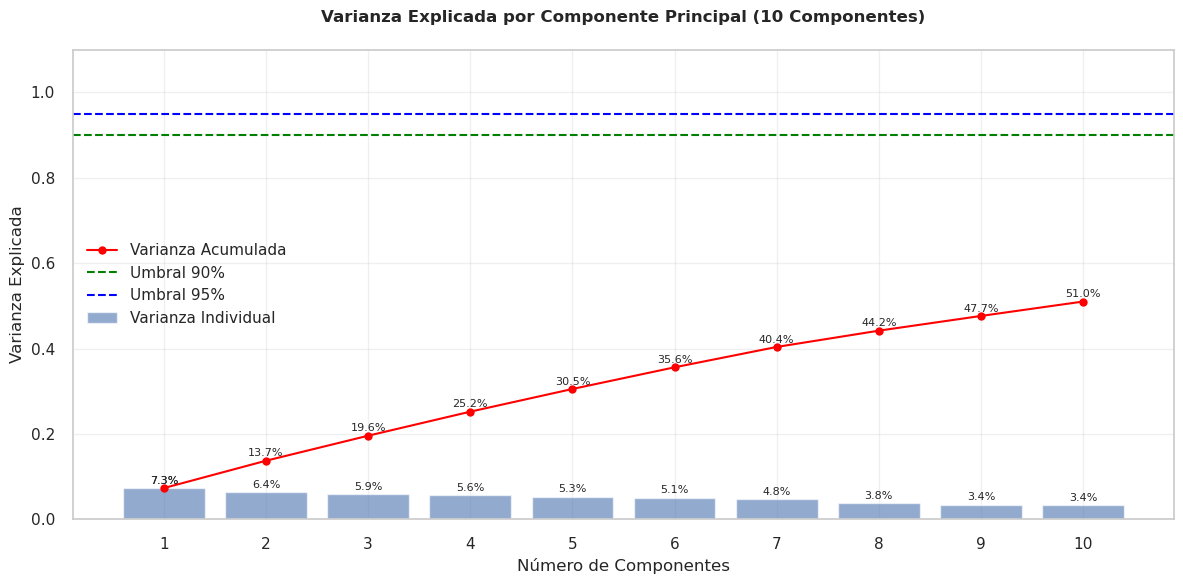

/tmp/ipykernel_6146/4150202715.py:79: FutureWarning:

Styler.applymap has been deprecated. Use Styler.map instead.



,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
SLA_Minutos,-0.080,0.255,0.095,0.028,0.043,-0.239,-0.148,-0.214,0.075,-0.105
Tipo_de_Caso_Requerimiento,-0.179,0.020,-0.023,-0.032,-0.030,0.007,0.011,0.189,-0.082,-0.058
Criticidad_BAJA,0.017,-0.056,0.038,-0.034,-0.046,0.089,0.074,-0.028,-0.092,0.016
Criticidad_MEDIA,0.211,0.136,-0.033,0.008,0.014,-0.046,0.003,0.097,-0.122,-0.095
Criticidad_MUY ALTA,-0.231,-0.106,0.014,-0.020,-0.048,0.008,-0.002,-0.143,0.242,0.082
Criticidad_OTROS,0.042,-0.054,-0.007,-0.012,-0.019,0.069,0.036,-0.039,-0.026,-0.098
Grupo_Resolutor_CAL - Aplicaciones,0.003,0.008,0.002,0.010,0.052,-0.026,0.070,0.254,0.207,-0.030
Grupo_Resolutor_CAL - Aplicaciones NO SAP,-0.069,-0.090,-0.005,-0.012,-0.017,0.029,0.094,0.010,-0.052,0.086
Grupo_Resolutor_CAL - Gestión Documental,-0.074,0.044,0.166,-0.014,-0.002,-0.131,0.184,-0.200,0.296,0.186
Grupo_Resolutor_CAL - Scada,-0.048,0.033,0.049,0.002,0.008,-0.198,0.256,0.033,-0.392,-0.168



🔍 INTERPRETACIÓN CLAVE POR COMPONENTE (10 Componentes):

PC1 (Explica 7.3% de varianza):
  - Variables con mayor carga POSITIVA: Torre_SAP, Grupo_Resolutor_PROV-AYESA - Soporte SAP
  - Variables con mayor carga NEGATIVA: Torre_APLICACIONES, Grupo_Resolutor_PROV-XTERNAL - Aplicaciones No Sap

PC2 (Explica 6.4% de varianza):
  - Variables con mayor carga POSITIVA: Grupo_Resolutor_PROV-AYESA - Soporte GIS, Aplicación_GIS
  - Variables con mayor carga NEGATIVA: Servicio_Servicio de Aplicaciones, Torre_APLICACIONES

PC3 (Explica 5.9% de varianza):
  - Variables con mayor carga POSITIVA: Servicio_10. RPA, Aplicación_AUTOMATIZACIÓN / RPA
  - Variables con mayor carga NEGATIVA: Aplicación_GIS, Grupo_Resolutor_PROV-AYESA - Soporte GIS

PC4 (Explica 5.6% de varianza):
  - Variables con mayor carga POSITIVA: Aplicación_ORACLE, Torre_ORACLE
  - Variables con mayor carga NEGATIVA: Grupo_Resolutor_PROV-AYESA - Soporte GIS, Aplicación_GIS

PC5 (Explica 5.3% de varianza):
  - Variables con mayor carg

In [98]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from IPython.display import display

# ------------------------------------------------------------
# 2. APLICACIÓN DE PCA (10 COMPONENTES)
# ------------------------------------------------------------

# Estandarización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca_base)

# PCA con 10 componentes
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

# Cálculo de métricas
varianza_individual = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_individual)
cargas = pca.components_.T  # Matriz de cargas (variables x componentes)

# ------------------------------------------------------------
# 3. VISUALIZACIÓN DE RESULTADOS
# ------------------------------------------------------------

# Configuración de estilos
plt.style.use('seaborn-v0_8')
sns.set_theme(style="whitegrid")

# ----------------------------------
# A. Gráfico de Varianza Acumulada (Ajustado para 10 componentes)
# ----------------------------------
plt.figure(figsize=(12, 6))
plt.bar(range(1, 11), varianza_individual, alpha=0.6, label='Varianza Individual')
plt.plot(range(1, 11), varianza_acumulada, marker='o', color='red', label='Varianza Acumulada')

# Líneas de referencia
plt.axhline(y=0.9, color='green', linestyle='--', label='Umbral 90%')
plt.axhline(y=0.95, color='blue', linestyle='--', label='Umbral 95%')

# Anotaciones
for i, (indiv, acu) in enumerate(zip(varianza_individual, varianza_acumulada)):
    plt.text(i+1, indiv+0.01, f"{indiv:.1%}", ha='center', fontsize=8)
    plt.text(i+1, acu+0.01, f"{acu:.1%}", ha='center', fontsize=8)

plt.title('Varianza Explicada por Componente Principal (10 Componentes)', pad=20)
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.1)
plt.xticks(range(1, 11))  # Asegurar que se muestren todos los componentes
plt.tight_layout()
plt.show()

# ----------------------------------
# B. Tabla de Cargas (Ajustada para 10 componentes)
# ----------------------------------
cargas_df = pd.DataFrame(
    cargas,
    columns=[f'PC{i+1}' for i in range(10)],
    index=variables_para_pca
)

print("\n📋 TABLA DE CARGAS (10 COMPONENTES)")

def color_cargas(val):
    color = 'red' if val > 0.5 else 'blue' if val < -0.5 else 'black'
    weight = 'bold' if abs(val) > 0.5 else 'normal'
    return f'color: {color}; font-weight: {weight}'

styled_table = (cargas_df.style
                .format("{:.3f}")
                .applymap(color_cargas)
                .set_properties(**{'text-align': 'center'})
                .set_table_styles([{
                    'selector': 'th',
                    'props': [('background-color', '#f0f0f0'), 
                             ('font-weight', 'bold'),
                             ('font-size', '12pt')]
                }])
                .set_caption("Cargas de las variables en cada componente principal (10 componentes)"))

display(styled_table)

# ----------------------------------
# C. Mapa de Calor Interactivo (Ajustado para 10 componentes)
# ----------------------------------
z = cargas_df.values.round(2)
x = [f'PC{i+1} ({var*100:.1f}%)' for i, var in enumerate(varianza_individual)]
y = cargas_df.index.tolist()

fig = go.Figure(data=go.Heatmap(
    z=z,
    x=x,
    y=y,
    colorscale='Oranges',
    zmin=-1,
    zmax=1,
    text=[[f"Variable: {y[i]}<br>Componente: {x[j]}<br>Carga: {z[i][j]:.2f}" 
           for j in range(len(x))] for i in range(len(y))],
    hoverinfo="text",
    showscale=True
))

# Añadir texto superpuesto
fig.add_trace(go.Scatter(
    x=np.repeat(x, len(y)),
    y=np.tile(y, len(x)),
    mode="text",
    text=[f"{val:.2f}" for row in z for val in row],
    textfont=dict(color="black", size=10),
    hoverinfo="skip"
))

fig.update_layout(
    title="Cargas de Variables en Componentes Principales (10 Componentes)",
    xaxis=dict(
        title="Componentes Principales (% Varianza Explicada)",
        tickangle=-45,
        side="top"
    ),
    yaxis=dict(
        title="Variables Originales",
        autorange='reversed'
    ),
    width=1200,
    height=2000,
    margin=dict(l=100, r=50, b=200, t=300),
    hoverlabel=dict(
        bgcolor="white",
        font_size=12,
        font_family="Arial"
    )
)

fig.show()

# ------------------------------------------------------------
# 4. ANÁLISIS INTERPRETATIVO (Ajustado para 10 componentes)
# ------------------------------------------------------------

print("\n🔍 INTERPRETACIÓN CLAVE POR COMPONENTE (10 Componentes):")
for i in range(10):
    pc_var = varianza_individual[i]
    top_pos = cargas_df.iloc[:, i].nlargest(2).index.tolist()
    top_neg = cargas_df.iloc[:, i].nsmallest(2).index.tolist()
    
    print(f"\nPC{i+1} (Explica {pc_var:.1%} de varianza):")
    print(f"  - Variables con mayor carga POSITIVA: {', '.join(top_pos)}")
    print(f"  - Variables con mayor carga NEGATIVA: {', '.join(top_neg)}")

# ------------------------------------------------------------
# 5. RECOMENDACIÓN FINAL
# ------------------------------------------------------------

umbral = 0.9
n_optimo = np.argmax(varianza_acumulada >= umbral) + 1

print(f"\n✅ RECOMENDACIÓN: Usar {n_optimo} componentes principales")
print(f"   - Explican el {varianza_acumulada[n_optimo-1]:.1%} de la varianza total")
print(f"   - Componentes seleccionados: {', '.join([f'PC{i+1}' for i in range(n_optimo)])}")

In [99]:
# ─────────────────────────────────────────────────────────────
# Paso Previo antes de Guardar tabla Gold - bd_aranda_gold_modelo
# ─────────────────────────────────────────────────────────────

# Variables a mantener explícitamente
columnas_finales_modelo = ['Caso', 'tiempo_resolucion_dias']

# Añadir todas las variables predictoras codificadas
# Excluimos 'Caso' porque ya está incluido y evitamos duplicados
columnas_predictoras = [col for col in df_modelo.columns if col not in columnas_finales_modelo]

# Construir DataFrame final
df_aranda_gold_modelo = df_modelo[columnas_finales_modelo + columnas_predictoras]

# Confirmación final
print("[INFO] DataFrame final para modelado generado exitosamente.")
print(f"       → Filas: {df_aranda_gold_modelo.shape[0]}")
print(f"       → Columnas: {df_aranda_gold_modelo.shape[1]}")
print(f"       → Incluye columna objetivo: {'tiempo_resolucion_dias' in df_aranda_gold_modelo.columns}")
print(f"       → Incluye columna 'Caso' para trazabilidad: {'Caso' in df_aranda_gold_modelo.columns}")
df_aranda_gold_modelo.info()

StatementMeta(, cac98411-7c8f-47bd-95e5-1d19256c3666, 101, Finished, Available, Finished)

[INFO] DataFrame final para modelado generado exitosamente.
       → Filas: 12736
       → Columnas: 66
       → Incluye columna objetivo: True
       → Incluye columna 'Caso' para trazabilidad: True
<class 'pandas.core.frame.DataFrame'>
Index: 12736 entries, 0 to 19745
Data columns (total 66 columns):
 #   Column                                                        Non-Null Count  Dtype 
---  ------                                                        --------------  ----- 
 0   Caso                                                          12736 non-null  object
 1   tiempo_resolucion_dias                                        12736 non-null  int64 
 2   SLA_Minutos                                                   12736 non-null  int64 
 3   Tipo_de_Caso_Requerimiento                                    12736 non-null  bool  
 4   Criticidad_BAJA                                               12736 non-null  bool  
 5   Criticidad_MEDIA                                             

In [100]:
# ─────────────────────────────────────────────────────────────
# Paso Final: Guardar tabla Gold - bd_aranda_gold_modelo
# ─────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd

# Reemplazar Inf y NaN por None para evitar errores de conversión
df_aranda_gold_modelo.replace([np.inf, -np.inf], np.nan, inplace=True)
df_aranda_gold_modelo = df_aranda_gold_modelo.where(pd.notnull(df_aranda_gold_modelo), None)

# Convertir a DataFrame Spark
# Limpieza de nombres de columnas
df_aranda_gold_modelo.columns = [
    col.replace(" ", "_")
       .replace("(", "")
       .replace(")", "")
       .replace("/", "_")
       .replace("-", "_")
       for col in df_aranda_gold_modelo.columns
]

# Convertir a Spark
df_spark_modelo = spark.createDataFrame(df_aranda_gold_modelo)


# Renombrar columnas para evitar espacios (recomendado en SQL)
df_spark_modelo_clean = df_spark_modelo.toDF(*[col.replace(" ", "_") for col in df_spark_modelo.columns])

# Nombre de la tabla en Gold
nombre_tabla_gold = "Gold.bd_aranda_gold_modelo"

# Eliminar si ya existe
spark.sql(f"DROP TABLE IF EXISTS {nombre_tabla_gold}")

# Guardar como tabla Delta
df_spark_modelo_clean.write.mode("overwrite").saveAsTable(nombre_tabla_gold)

print("✅ Tabla 'bd_aranda_gold_modelo' guardada exitosamente en Gold.")




StatementMeta(, cac98411-7c8f-47bd-95e5-1d19256c3666, 102, Finished, Available, Finished)

✅ Tabla 'bd_aranda_gold_modelo' guardada exitosamente en Gold.


In [101]:
%%sql
select *  from Gold.bd_aranda_gold_modelo 

StatementMeta(, cac98411-7c8f-47bd-95e5-1d19256c3666, 103, Finished, Available, Finished)

<Spark SQL result set with 1000 rows and 66 fields>